In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visa_df = pd.read_csv(r"C:\Users\Kasipetaraviteja\Documents\Data_files\Visadataset.csv")
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [3]:
## seperate the categorical and numerical

In [4]:
cat = visa_df.select_dtypes(include='object').columns.tolist()
num = visa_df.select_dtypes(exclude='object').columns.tolist()


-  we did only categorical

-  we did only numerical

- now ==  multiple column analysis

- lets assume continent vs casestatus

- we jnow diff applicants from diff diff continents

- in that some are certified and some are denied

## BiVaraite

- two column comparision

In [ ]:
# no . of Asia applicants who are 

In [5]:
## doing for both (continent and case status)
#                         Asia          Certified
con1 = visa_df['continent'] == 'Asia'
con2 = visa_df['case_status'] == 'Denied'
certi_count = np.sum(con1&con2)
certi_count

np.int64(5849)

In [6]:
visa_df[con1&con2]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
11,EZYV12,Asia,High School,Y,N,4069,2005,Northeast,70813.0900,Year,Y,Denied
15,EZYV16,Asia,High School,Y,N,4897,1987,West,74108.0200,Year,Y,Denied
...,...,...,...,...,...,...,...,...,...,...,...,...
25450,EZYV25451,Asia,Bachelor's,N,N,3312,2009,Northeast,682.1048,Hour,Y,Denied
25452,EZYV25453,Asia,High School,N,N,70,1995,Northeast,84833.8900,Year,Y,Denied
25454,EZYV25455,Asia,Bachelor's,N,N,1316,2007,South,62844.9700,Year,Y,Denied
25459,EZYV25460,Asia,High School,Y,N,4727,1990,Midwest,53952.8400,Year,Y,Denied


In [7]:
con1 = visa_df['continent'] == 'Asia'
con2 = visa_df['case_status'] == 'Certified'
certi_count = np.sum(con1&con2)
certi_count

np.int64(11012)

In [8]:
continents = visa_df['continent'].unique().tolist()
case_status = visa_df['case_status'].unique().tolist()
print(continents)
clist = []
dlist = []
for i in continents:
    con1 = visa_df['continent'] == i
    con2 = visa_df['case_status'] == 'Certified'
    certi_count = np.sum(con1&con2)
    clist.append(certi_count)
    
    con3 = visa_df['case_status'] == 'Denied'
    deni_count = np.sum(con1&con3)
    dlist.append(deni_count)
print(clist)
print(dlist)

['Asia', 'Africa', 'North America', 'Europe', 'South America', 'Oceania']
[np.int64(11012), np.int64(397), np.int64(2037), np.int64(2957), np.int64(493), np.int64(122)]
[np.int64(5849), np.int64(154), np.int64(1255), np.int64(775), np.int64(359), np.int64(70)]


In [9]:
df =pd.DataFrame(zip(clist,dlist),index=continents,columns=['Certified','Denied'])
df.index.name='continent'
df

,Certified,Denied
continent,,
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


## crosstab

In [ ]:
pd.crosstab(index ,  columns)

# pd.crosstab ( 'continent' , 'case_status')


In [12]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
pd.crosstab(col1 , col2)              # col1 == index, col=2 === column

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


## MultiVaraite

-  more than two columns comparision or relationship

In [50]:
# More than 2 columns
# we are checking the relation b/w the more than 2 columns

In [13]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
col3 = visa_df['education_of_employee']
pd.crosstab(col1,[col2,col3])

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

<Axes: xlabel='continent'>

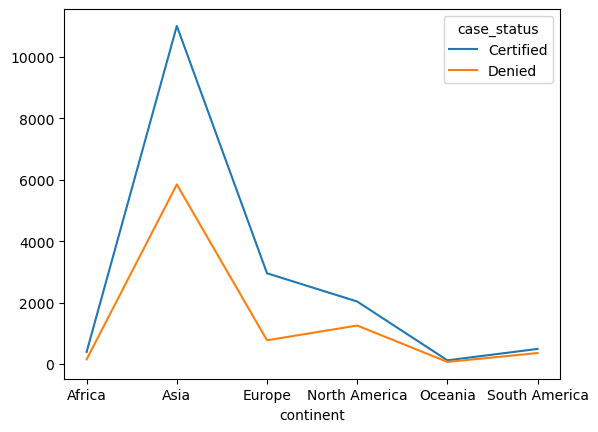

In [14]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
r1 = pd.crosstab(col1,col2)
r1.plot()

In [15]:
pd.crosstab(col2,col1)

continent,Africa,Asia,Europe,North America,Oceania,South America
case_status,,,,,,
Certified,397,11012,2957,2037,122,493
Denied,154,5849,775,1255,70,359


<Axes: xlabel='continent'>

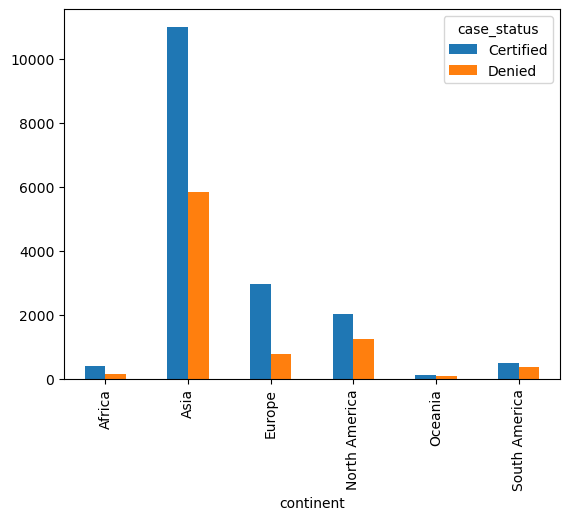

In [16]:
r1.plot(kind='bar')

In [12]:
col1

0          Asia
1          Asia
2          Asia
3          Asia
4        Africa
          ...  
25475      Asia
25476      Asia
25477      Asia
25478      Asia
25479      Asia
Name: continent, Length: 25480, dtype: object

In [14]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


<Axes: xlabel='education_of_employee,has_job_experience'>

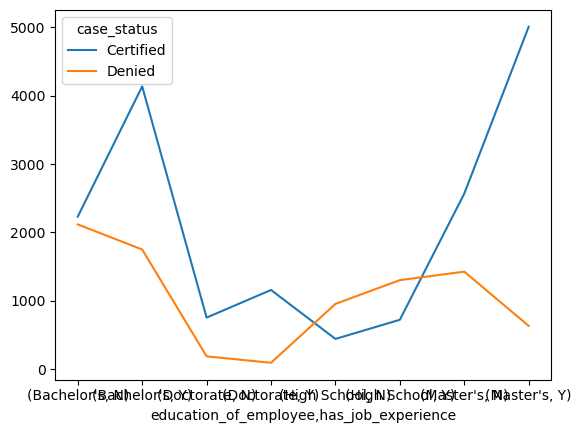

In [24]:
col1 = visa_df['has_job_experience']
col2 = visa_df['case_status']
col3 = visa_df['education_of_employee']
r1 = pd.crosstab([col3,col1], col2)
r1.plot()

## categorical : **Frequency table , Bar/Pie chart
## Numerical  : Histogram/boxplot
## Categorical vs Categorical  : pd.crosstab
## Numerical vs Numerical   : scatterplots, covaraince, correlation

# Scattetplots

- it is graph representation b/w two numerical columns

- it is also gives the relationship status b/w the two columns

    - positive , negative or no relation

- scatter  ========> **gives the (dots)**  data points(x,y)

- plot     =======> **will attach those points with Line**

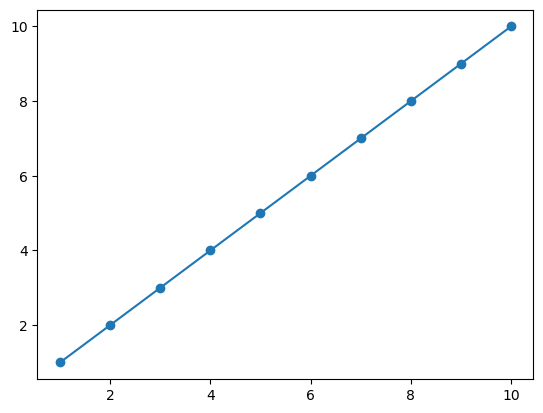

In [17]:
x = range(1,11)
y = range(1,11)
plt.scatter(x,y)  
plt.plot(x,y)
plt.savefig('scatterplot.jpg')
plt.show()

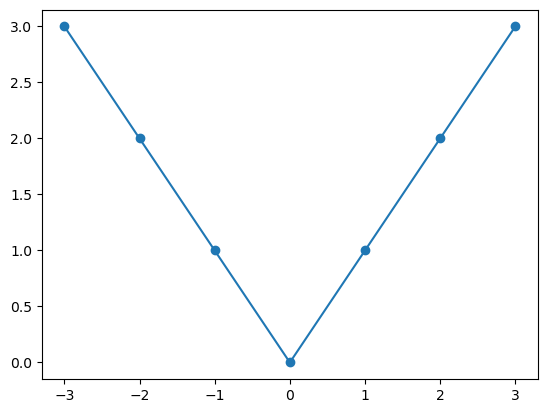

In [18]:
x = range(-3,4)
y = np.abs(x)
plt.scatter(x,y)
plt.plot(x,y)

In [19]:
np.abs(-9)

np.int64(9)

In [51]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


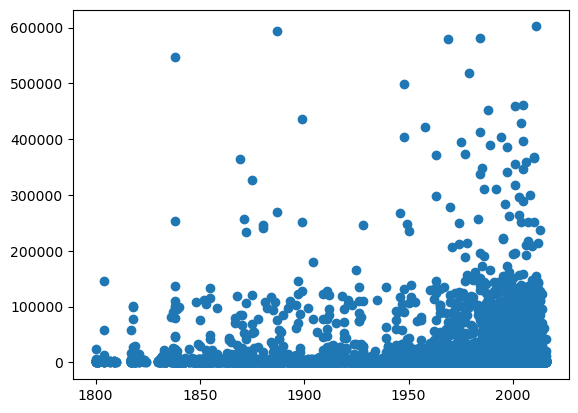

In [20]:
x = visa_df['no_of_employees']	
y = visa_df['yr_of_estab']
plt.subplot(1,1,1).scatter(y,x)
#plt.plot(x,y)

# x ========> no.of employees
# y ========> year

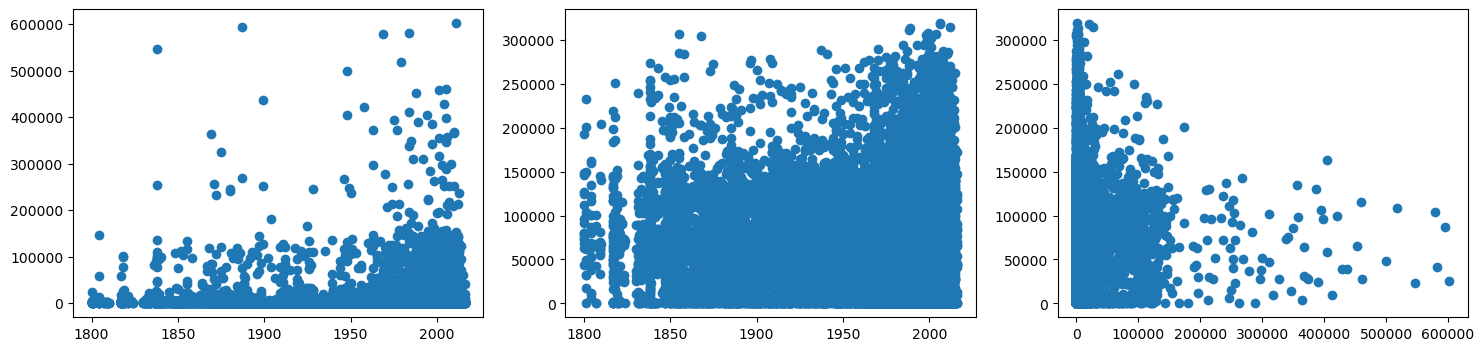

In [21]:
col1 = visa_df['no_of_employees']
col2 = visa_df['yr_of_estab']
col3 = visa_df['prevailing_wage']
plt.figure(figsize=(18,4))
plt.subplot(1,3,1).scatter(col2,col1)
plt.subplot(1,3,2).scatter(col2,col3)
plt.subplot(1,3,3).scatter(col1,col3)
plt.show()

-  we have drawn the scatter plots for the numerical columns

- by seeing above plots , we are not able to identify the relation

- to get more confidence will go to correlation matrix

## correlation matrix

In [ ]:
visa_df.corr(numeric_only: 'bool' = False,)

In [32]:
visa_df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


## conclusion of correlation on visa_df 

- by seeing the above correlation matrix

    -  we can say that **there is no relation b/w them **
    
        - they are **independent to each other**  

        - Bcoz , some are negative and postive ,  But they are **very close to ZERO**

- diagonal elements : Dont consider , Bcoz, they are self relation,
        
    - pakka , there **will be postive relation only** 1.00

In [ ]:
- in your datfiles : winequality

- read the df

-  perform the correlatin matrix : 

- do you analysiz yourself immediately ,
    - which column has high +ve realtion

    - high -ve relation

In [33]:
wine_df =pd.read_csv(r"C:\Users\Kasipetaraviteja\Documents\Data_files\winequality_red.csv")

In [34]:
wine_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [36]:
wine_df.corr(numeric_only=True)    # all are numeric columns only .So no need of numeric_only=True

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


## **heatmap()**

- it is under **seaborn package**

- any math can be graphical by this seaborn package

- bax, histogram, distribution, boxplot, etc can be done by the seaborn

### colours will tell you the relation

#### heatmap( correlation matrix )

<Axes: >

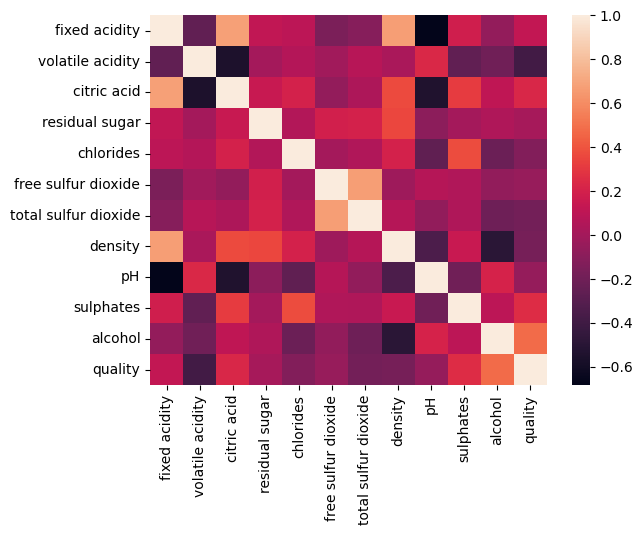

In [43]:
import seaborn as sns
sns.heatmap(wine_df.corr())

In [ ]:
from above we can say 

right side there is values and color 

  1.0  ← very light / cream
  0.8
  0.6
  0.4
  0.2
  0.0  ← pinkish
 -0.2
 -0.4
 -0.6  ← very dark / black-purple

- IGNORE   : Diagonal cells , bocz they are self realtions

- choose the very light  for high +ve relation

- choose the vey dark black : for high -ve realtion

###  annot = True  ===> will give the relation values (-1 to +1)

<Axes: >

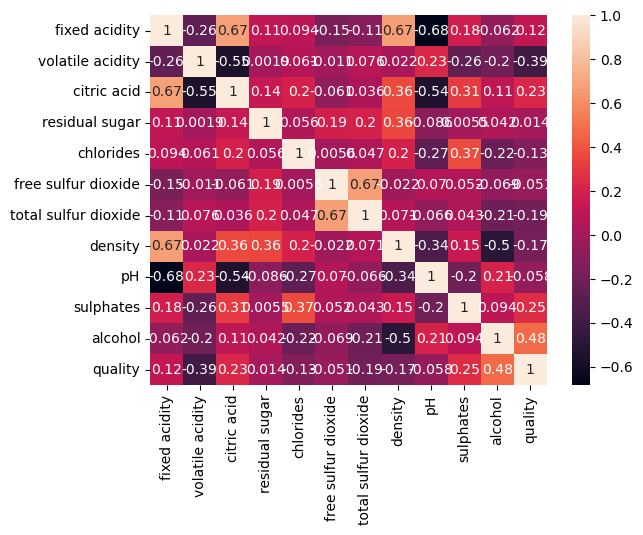

In [44]:
sns.heatmap(wine_df.corr(),
           annot=True)        # annot = True  ===> will give the relation values (-1 to +1)

<Axes: >

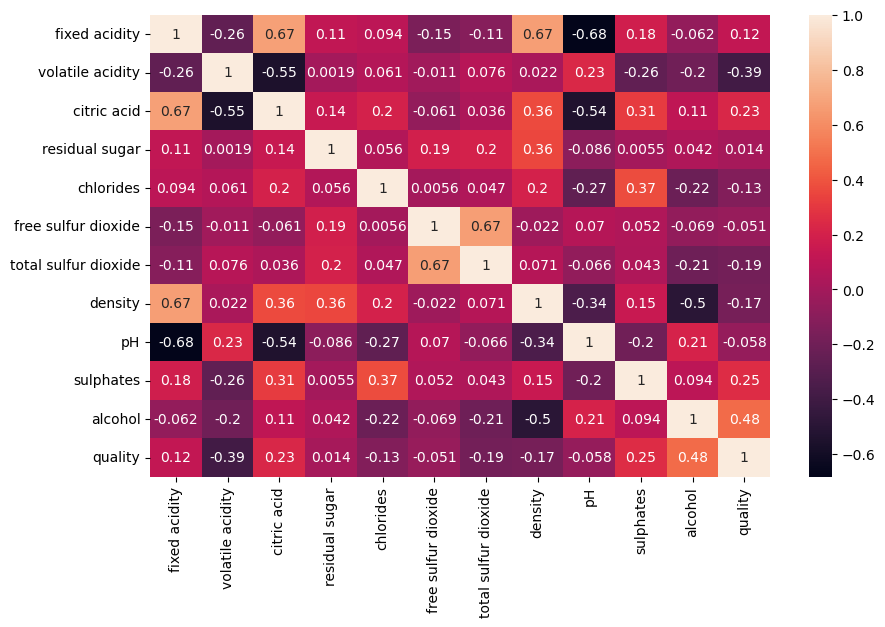

In [46]:
plt.figure(figsize=(10,6))
sns.heatmap(wine_df.corr(),
           annot=True)

In [ ]:
HIGH +ve Correlation
-----------------------
from above we can 0.67  ===> there are multiple columns are correlated each other
                                            by the same value
                            you can choose any one of them
Ex: free sulfur dioxide and total sulfur dioxide    ( select)  

HIGH -ve Correlation
-----------------------

from above we can 0.54  ===> 

citric acid   and pH ( select)        It has the nearest to -1  ( strong)